In [37]:
#!/usr/bin/env python3
"""
Re-pull all MediEvil (1998) runs from speedrun.com and build a clean flattened dataset.

What this does:
- Downloads all runs for MediEvil (all players, all categories).
- Fetches category + subcategory variable metadata.
- Fetches usernames for all user IDs.
- Builds a flat structure with:
    - category_name         (e.g. "Beat the Game")
    - subcategory_name      (e.g. "Any%", "Any% (No DGS)")
    - full_category         (e.g. "Beat the Game – Any% (No DGS)")
    - time_seconds          (from times.realtime_t)
    - run_date              (verify-date or submitted)
    - platform, emulated
    - main_player_id, main_player_name
- Saves:
    - data/medievil_runs_raw.json
    - data/medievil_runs_flat.json
"""

import json
import time
from pathlib import Path

import requests
import pandas as pd

BASE_URL = "https://www.speedrun.com/api/v1"
GAME_ID = "o6gl49d2"  # MediEvil (1998)
SESSION = requests.Session()


# ----------------------------
# Helpers: API calls
# ----------------------------

def fetch_all_runs_for_game(game_id,
                            max_per_page=200,
                            status=None,
                            delay_seconds=0.7):
    """
    Fetch all runs for a given game ID from /runs, handling pagination.

    - Does NOT trust pagination.size.
    - Keeps requesting pages until an empty or short page comes back.
    """
    all_runs = []
    offset = 0

    while True:
        params = {
            "game": game_id,
            "max": max_per_page,
            "offset": offset,
        }
        if status:
            params["status"] = status

        url = f"{BASE_URL}/runs"
        resp = SESSION.get(url, params=params)
        resp.raise_for_status()
        payload = resp.json()

        runs = payload.get("data", [])
        num = len(runs)

        print("Fetched {} runs (offset={}), total so far: {}".format(
            num, offset, len(all_runs)
        ))

        if not runs:
            break

        all_runs.extend(runs)

        # if we got fewer than max_per_page, that was the last page
        if num < max_per_page:
            break

        offset += max_per_page
        time.sleep(delay_seconds)

    return all_runs


def get_game_categories(game_id):
    """
    Return list of categories for a given game.
    """
    url = f"{BASE_URL}/games/{game_id}/categories"
    resp = SESSION.get(url)
    resp.raise_for_status()
    return resp.json()["data"]


def get_category_variables(cat_id):
    """
    Return list of variables for a given category.
    """
    url = f"{BASE_URL}/categories/{cat_id}/variables"
    resp = SESSION.get(url)
    # Some weird/legacy category IDs might 404; handle gracefully.
    if resp.status_code == 404:
        print("Warning: /categories/{} /variables returned 404.".format(cat_id))
        return []
    resp.raise_for_status()
    return resp.json()["data"]


def get_user(user_id):
    """
    Fetch a single user object by ID.
    """
    url = f"{BASE_URL}/users/{user_id}"
    resp = SESSION.get(url)
    if resp.status_code == 404:
        print("Warning: user {} returned 404.".format(user_id))
        return None
    resp.raise_for_status()
    return resp.json()["data"]


def build_user_name_map(runs,
                        delay_seconds=0.4):
    """
    Scan all runs, collect unique 'user' IDs, and fetch their usernames.

    Returns:
        user_name_map[user_id] = username (international name)
    """
    user_ids = set()

    for run in runs:
        players = run.get("players", [])
        for p in players:
            if p.get("rel") == "user":
                uid = p.get("id")
                if uid:
                    user_ids.add(uid)

    print("Found {} unique user IDs.".format(len(user_ids)))

    user_name_map = {}
    for i, uid in enumerate(sorted(user_ids)):
        data = get_user(uid)
        if data is None:
            continue
        names = data.get("names", {})
        # Prefer 'international' name, fallback to 'international' key or id
        username = names.get("international") or data.get("name") or uid
        user_name_map[uid] = username
        print("  [{}/{}] {} -> {}".format(i + 1, len(user_ids), uid, username))
        time.sleep(delay_seconds)  # be nice to the API

    return user_name_map


# ----------------------------
# Flattening helpers
# ----------------------------

def parse_run_date(run):
    """
    Choose a single run_date:
    - Prefer status.verify-date
    - Fallback to submitted
    Returns a pandas.Timestamp or NaT.
    """
    status = run.get("status") or {}
    verify_date = status.get("verify-date")
    submitted = run.get("submitted")

    for d in (verify_date, submitted):
        if d:
            dt = pd.to_datetime(d, errors="coerce")
            if pd.notna(dt):
                return dt

    return pd.NaT


def build_subcategory_metadata(game_id):
    """
    Build:
    - cat_name_map[cat_id] = category_name
    - subcat_vars[cat_id][var_id] = {
        "name": var_name,
        "values": { value_id: label, ... }
      }
    where variables are only those used as subcategories (is-subcategory=True).
    """
    categories = get_game_categories(game_id)
    cat_name_map = {c["id"]: c["name"] for c in categories}

    subcat_vars = {}

    for c in categories:
        cat_id = c["id"]
        vars_data = get_category_variables(cat_id)
        sub_vars_for_cat = {}

        for v in vars_data:
            if not v.get("is-subcategory"):
                continue
            var_id = v["id"]
            var_name = v["name"]
            values = v["values"]["values"]  # dict: value_id -> {...}
            value_labels = {vid: vinfo["label"] for vid, vinfo in values.items()}
            sub_vars_for_cat[var_id] = {
                "name": var_name,
                "values": value_labels,
            }

        if sub_vars_for_cat:
            subcat_vars[cat_id] = sub_vars_for_cat

    return cat_name_map, subcat_vars


def flatten_run_with_subcats(run,
                             cat_name_map,
                             subcat_vars,
                             user_name_map):
    """
    Flatten a raw run JSON into a single record, using:
    - category_name and subcategory variables to derive full_category
    - realtime_t as time_seconds (MediEvil uses realtime)
    - user_name_map to attach usernames
    """
    times = run.get("times", {})
    system = run.get("system", {})
    status = run.get("status") or {}
    players = run.get("players", [])
    values = run.get("values", {})  # variable_id -> value_id

    # Player IDs (first one is main_player)
    player_ids = []
    for p in players:
        rel = p.get("rel")
        if rel == "user":
            player_ids.append(p.get("id"))
        elif rel == "guest":
            player_ids.append("guest:{}".format(p.get("name")))
    main_player_id = player_ids[0] if player_ids else None

    # Username for main player (if it's a real user)
    main_player_name = None
    if main_player_id and not main_player_id.startswith("guest:"):
        main_player_name = user_name_map.get(main_player_id)
    elif main_player_id and main_player_id.startswith("guest:"):
        # For guests, embed the guest name directly
        main_player_name = main_player_id.split("guest:", 1)[1]

    cat_id = run.get("category")
    cat_name = cat_name_map.get(cat_id, cat_id)

    # Build subcategory label from subcategory-type variables
    sub_label_parts = []
    sub_vars_for_cat = subcat_vars.get(cat_id, {})
    for var_id, meta in sub_vars_for_cat.items():
        val_id = values.get(var_id)
        if not val_id:
            continue
        val_label = meta["values"].get(val_id, val_id)
        # Usually variable name is redundant (e.g. "Category: Any%"),
        # so we keep only the value label.
        sub_label_parts.append(val_label)

    if sub_label_parts:
        subcategory_name = " | ".join(sub_label_parts)
        full_category = "{} – {}".format(cat_name, subcategory_name)
    else:
        subcategory_name = None
        full_category = cat_name

    return {
        "run_id": run.get("id"),
        "game_id": run.get("game"),

        "category_id": cat_id,
        "category_name": cat_name,
        "subcategory_name": subcategory_name,
        "full_category": full_category,

        "status": status.get("status"),
        "verify_date": status.get("verify-date"),
        "submitted": run.get("submitted"),
        "run_date": parse_run_date(run),

        "weblink": run.get("weblink"),

        # MediEvil: use realtime_t as the canonical time
        "realtime_seconds": times.get("realtime_t"),

        "platform": system.get("platform"),
        "emulated": system.get("emulated"),

        # Players (IDs only, comma-separated)
        "players": ",".join(player_ids),

        # Main player: both ID and username
        "main_player_id": main_player_id,
        "main_player_name": main_player_name,

        # Keep raw values dict so we can inspect variables later if needed
        "values": values,
    }


# ----------------------------
# Main flow
# ----------------------------

def main():
    out_dir = Path("data")
    out_dir.mkdir(exist_ok=True)

    # 1) Re-pull all runs
    print("Fetching ALL runs for MediEvil (1998) from speedrun.com...")
    runs = fetch_all_runs_for_game(
        game_id=GAME_ID,
        max_per_page=200,
        status=None,        # or "verified" if you want only verified runs
        delay_seconds=0.7,
    )
    print("Total raw runs fetched: {}".format(len(runs)))

    raw_path = out_dir / "medievil_runs_raw.json"
    with raw_path.open("w", encoding="utf-8") as f:
        json.dump(runs, f, ensure_ascii=False, indent=2)
    print("Saved raw runs to {}".format(raw_path))

    # 2) Build category + subcategory metadata
    print("Fetching category and subcategory metadata...")
    cat_name_map, subcat_vars = build_subcategory_metadata(GAME_ID)
    print("Found {} categories.".format(len(cat_name_map)))
    print("Found subcategory variables for {} categories.".format(len(subcat_vars)))

    # 3) Build user_id -> username map
    print("Fetching usernames for all players...")
    user_name_map = build_user_name_map(runs)
    print("Collected usernames for {} users.".format(len(user_name_map)))

    # 4) Flatten runs with enriched category + username info
    print("Flattening runs...")
    flat_records = [
        flatten_run_with_subcats(run, cat_name_map, subcat_vars, user_name_map)
        for run in runs
    ]
    df = pd.DataFrame(flat_records)

    # basic cleaning: drop runs with no time or no date
    before = len(df)
    df = df[df["realtime_seconds"].notna()].copy()
    df = df[df["run_date"].notna()].copy()
    after = len(df)
    print("Dropped {} runs with missing time/date. Remaining: {}".format(
        before - after, after
    ))

    # 5) Save as JSON (make datetimes serializable)
    flat_path = out_dir / "medievil_runs_flat.json"

    df_to_save = df.copy()
    # convert run_date to string
    for col in ["run_date"]:
        if col in df_to_save.columns:
            df_to_save[col] = df_to_save[col].astype(str)

    records = df_to_save.to_dict(orient="records")

    with flat_path.open("w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    print("Saved flattened runs to {}".format(flat_path))

    print("\nExample categories (full_category):")
    print(df["full_category"].value_counts().head(10))


if __name__ == "__main__":
    main()


Fetching ALL runs for MediEvil (1998) from speedrun.com...
Fetched 200 runs (offset=0), total so far: 0
Fetched 148 runs (offset=200), total so far: 200
Total raw runs fetched: 348
Saved raw runs to data/medievil_runs_raw.json
Fetching category and subcategory metadata...
Found 3 categories.
Found subcategory variables for 3 categories.
Fetching usernames for all players...
Found 51 unique user IDs.
  [1/51] 0jm346z8 -> Marsh_GL
  [2/51] 18q2z78n -> Jaxler
  [3/51] 48g5orjp -> Brescaz
  [4/51] 5j5g34n8 -> DeoChomp
  [5/51] 8d0wp7ox -> crazyfrog
  [6/51] 8g5n65yj -> toxic4k
  [7/51] 8gz5d37j -> FizzyRingo
  [8/51] 8l02lgv8 -> BlackMenthol
  [9/51] 8l67on48 -> YENOOL
  [10/51] 8lrqpv78 -> Fullshark09
  [11/51] 8q006pdj -> hjalmarr_
  [12/51] 8qrrp27j -> TedFeds
  [13/51] 8r21w6dx -> Zillk
  [14/51] 8r6pw9d8 -> forajido89
  [15/51] 8v0kwqyx -> LeonMauriceMan
  [16/51] 98r11yqj -> JacoboTheChocobo
  [17/51] 98r7pwj1 -> LukeRF44
  [18/51] dkjpwkxq -> Crash41596
  [19/51] dx37p9e8 -> matchle

In [55]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.dates as mdates

flat_path = Path("data/medievil_runs_flat.json")
with flat_path.open("r", encoding="utf-8") as f:
    records = json.load(f)

df = pd.DataFrame(records)

# Turn run_date back into datetime for analysis
df["run_date"] = pd.to_datetime(df["run_date"], errors="coerce")

df["full_category"].value_counts()
df

,run_id,game_id,category_id,category_name,subcategory_name,full_category,status,verify_date,submitted,run_date,weblink,realtime_seconds,platform,emulated,players,main_player_id,main_player_name,values
0,9megn3y7,o6gl49d2,7dgo894k,Full Completion,All Chalice | Emulator | NTSC,Full Completion – All Chalice | Emulator | NTSC,verified,None,2014-11-25T00:43:45Z,2014-11-25 00:43:45+00:00,http://www.speedrun.com/medievil/run/9megn3y7,5778.000,wxeod9rn,True,98r7pwj1,98r7pwj1,LukeRF44,"{'ql69ykjl': '10v3d7ol', '6njp17pn': '1dkre2pl..."
1,wzpxkgmq,o6gl49d2,xd1vgv4d,Beat the Game,Any% (No DGS) | Emulator | NTSC,Beat the Game – Any% (No DGS) | Emulator | NTSC,verified,None,2014-11-25T00:58:02Z,2014-11-25 00:58:02+00:00,http://www.speedrun.com/medievil/run/wzpxkgmq,3156.000,wxeod9rn,True,dx3m678l,dx3m678l,Cladall,"{'dloeozrn': 'ln8royjl', '9l7xx09n': '81wzz6m1..."
2,nz1nv9ye,o6gl49d2,xd1vgv4d,Beat the Game,Any% (No DGS) | Emulator | NTSC,Beat the Game – Any% (No DGS) | Emulator | NTSC,verified,None,2014-11-25T01:29:42Z,2014-11-25 01:29:42+00:00,http://www.speedrun.com/medievil/run/nz1nv9ye,2931.000,wxeod9rn,True,48g5orjp,48g5orjp,Brescaz,"{'dloeozrn': 'ln8royjl', '9l7xx09n': '81wzz6m1..."
3,1zqpj8ml,o6gl49d2,xd1vgv4d,Beat the Game,Any% (No DGS) | Console | NTSC,Beat the Game – Any% (No DGS) | Console | NTSC,verified,None,2014-11-25T13:09:16Z,2014-11-25 13:09:16+00:00,http://www.speedrun.com/medievil/run/1zqpj8ml,3258.000,n5e17e27,False,dkjpwkxq,dkjpwkxq,Crash41596,"{'dloeozrn': 'ln8royjl', '9l7xx09n': '5lmvv78l..."
4,7z00j8z5,o6gl49d2,xd1vgv4d,Beat the Game,Any% (No DGS) | Console | NTSC,Beat the Game – Any% (No DGS) | Console | NTSC,verified,None,2014-11-25T13:54:58Z,2014-11-25 13:54:58+00:00,http://www.speedrun.com/medievil/run/7z00j8z5,3464.000,n5e17e27,False,qjo21e86,qjo21e86,Alowishus89,"{'dloeozrn': 'ln8royjl', '9l7xx09n': '5lmvv78l..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,zx529dgm,o6gl49d2,xd1vgv4d,Beat the Game,Any% (No DGS) | Emulator | NTSC,Beat the Game – Any% (No DGS) | Emulator | NTSC,verified,2025-10-18T15:03:34Z,2025-10-18T07:41:57Z,2025-10-18 15:03:34+00:00,http://www.speedrun.com/medievil/run/zx529dgm,2069.000,wxeod9rn,True,x7q22yy8,x7q22yy8,Nazzareno,"{'dloeozrn': 'ln8royjl', '9l7xx09n': '81wzz6m1..."
344,yw588q2y,o6gl49d2,xd1vgv4d,Beat the Game,Any% (No DGS) | Emulator | NTSC,Beat the Game – Any% (No DGS) | Emulator | NTSC,verified,2025-10-19T09:10:48Z,2025-10-19T07:47:37Z,2025-10-19 09:10:48+00:00,http://www.speedrun.com/medievil/run/yw588q2y,2049.000,wxeod9rn,True,x7q22yy8,x7q22yy8,Nazzareno,"{'dloeozrn': 'ln8royjl', '9l7xx09n': '81wzz6m1..."
345,zp51kkny,o6gl49d2,jdr5qwgk,Miscellaneous,Max% Glitchless | Emulator | NTSC,Miscellaneous – Max% Glitchless | Emulator | NTSC,verified,2025-11-16T20:57:22Z,2025-11-11T18:18:13Z,2025-11-16 20:57:22+00:00,http://www.speedrun.com/medievil/run/zp51kkny,5840.000,wxeod9rn,True,zx7mzqx7,zx7mzqx7,NoobKillerRoof,"{'2lgkkr38': 'lmojor01', '789ee66l': 'q65k59ol..."
346,zq515drz,o6gl49d2,xd1vgv4d,Beat the Game,Any% (Glitchless) | Emulator | NTSC,Beat the Game – Any% (Glitchless) | Emulator...,new,None,2025-11-12T05:46:55Z,2025-11-12 05:46:55+00:00,http://www.speedrun.com/medievil/run/zq515drz,6183.160,wxeod9rn,True,v8lpnlvj,v8lpnlvj,CraftiePlays,"{'dloeozrn': '1py85x81', '9l7xx09n': '81wzz6m1..."


In [60]:
def pb_timeline(df, player_id, full_category=None):
    sub = df[df["main_player_id"] == player_id].copy()
    if full_category is not None:
        sub = sub[sub["full_category"] == full_category].copy()
    sub = sub.sort_values("run_date")
    if sub.empty:
        return sub
    sub["pb_so_far"] = sub["realtime_seconds"].cummin()
    return sub[["run_date", "pb_so_far"]]

def wr_timeline(df, full_category=None):
    sub = df.copy()
    if full_category is not None:
        sub = sub[sub["full_category"] == full_category].copy()
    sub = sub.sort_values("run_date")
    if sub.empty:
        return sub
    sub["wr_so_far"] = sub["realtime_seconds"].cummin()
    return sub[["run_date", "wr_so_far"]]

def seconds_to_mmss(x, pos):
    if x is None or pd.isna(x):
        return ""
    x = float(x)
    m = int(x // 60)
    s = int(round(x - m * 60))
    if s == 60:  # edge case
        m += 1
        s = 0
    return f"{m:02d}:{s:02d}"

def quarter_formatter(x, pos):
    dt = mdates.num2date(x)
    q = dt.month
    return f"{dt.year}-{q}"

14 players in Beat the Game – Any% | Emulator | NTSC


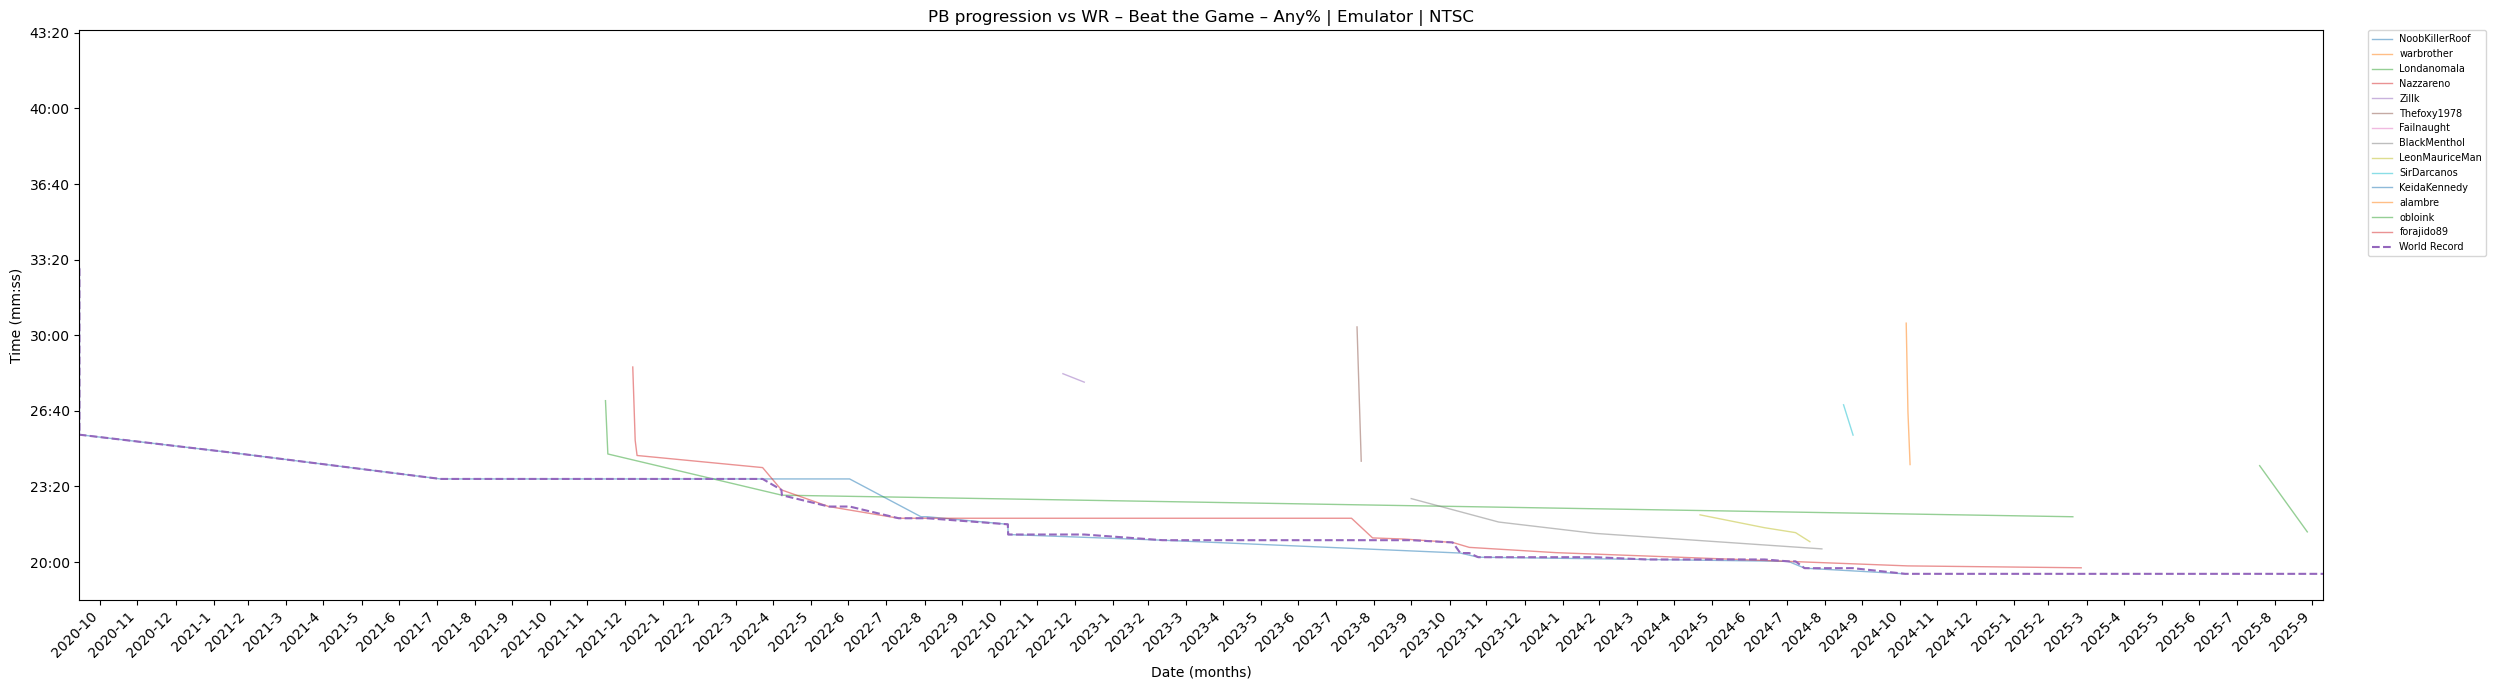

In [65]:
df["run_date"] = pd.to_datetime(df["run_date"], errors="coerce")
df = df[df["run_date"].notna()].copy()

full_cat = "Beat the Game – Any% | Emulator | NTSC"  # example string

subset = df[df["full_category"] == full_cat].copy()

fig, ax = plt.subplots(figsize=(25, 7))  # wider figure

# Y axis as mm:ss
ax.yaxis.set_major_formatter(ticker.FuncFormatter(seconds_to_mmss))

# All players in this category
players_in_cat = subset["main_player_id"].dropna().unique()
print(f"{len(players_in_cat)} players in {full_cat}")

for pid in players_in_cat:
    sub = pb_timeline(subset, pid, full_category=full_cat)
    if sub.empty:
        continue
    name_series = subset[subset["main_player_id"] == pid]["main_player_name"].dropna()
    label = name_series.iloc[0] if not name_series.empty else pid
    ax.plot(sub["run_date"], sub["pb_so_far"], linewidth=1, alpha=0.5, label=label)

# WR line
wr = wr_timeline(subset, full_category=full_cat)
if not wr.empty:
    ax.plot(wr["run_date"], wr["wr_so_far"], linestyle="--", label="World Record")

# X axis: ticks at quarter start
min_date = subset["run_date"].min()
max_date = subset["run_date"].max()
quarters = pd.date_range(min_date, max_date, freq="ME")  # quarter start

ax.set_xticks(quarters)
ax.set_xlim(min_date, max_date)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(quarter_formatter))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_xlabel("Date (months)")
ax.set_ylabel("Time (mm:ss)")
ax.set_title(f"PB progression vs WR – {full_cat}")

# Legend (optional: comment out if too cluttered)
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)

fig.tight_layout()
plt.show()

In [66]:
full_cat = "Beat the Game – Any% | Emulator | NTSC"

sub = df[df["full_category"] == full_cat].copy()
sub = sub.sort_values("run_date")

sub["wr_so_far"] = sub["realtime_seconds"].cummin()

print("Global min time:", sub["realtime_seconds"].min())
print("Last WR value :", sub["wr_so_far"].iloc[-1])

# Inspect last few WR updates
sub_wr_updates = sub.loc[sub["wr_so_far"].diff().fillna(0) != 0,
                         ["run_date", "realtime_seconds", "wr_so_far",
                          "main_player_name", "weblink"]]
sub_wr_updates.tail(15)

Global min time: 1169.0
Last WR value : 1169.0


,run_date,realtime_seconds,wr_so_far,main_player_name,weblink
155,2022-05-07 15:46:56+00:00,1391.0,1391.0,Nazzareno,http://www.speedrun.com/medievil/run/y60rw66y
157,2022-05-08 00:49:10+00:00,1377.0,1377.0,Londanomala,http://www.speedrun.com/medievil/run/y88v3wxy
166,2022-06-15 01:52:56+00:00,1347.0,1347.0,Nazzareno,http://www.speedrun.com/medievil/run/yvrp8e8z
169,2022-08-10 20:28:58+00:00,1316.0,1316.0,Nazzareno,http://www.speedrun.com/medievil/run/y9x5vrey
174,2022-11-07 10:33:09+00:00,1300.0,1300.0,NoobKillerRoof,http://www.speedrun.com/medievil/run/zpd8p0vz
175,2022-11-07 10:33:12+00:00,1297.0,1297.0,NoobKillerRoof,http://www.speedrun.com/medievil/run/znq0ervz
182,2022-11-07 16:11:45+00:00,1273.0,1273.0,NoobKillerRoof,http://www.speedrun.com/medievil/run/yd1x8vjy
188,2023-03-12 23:04:28+00:00,1258.0,1258.0,NoobKillerRoof,http://www.speedrun.com/medievil/run/y4gj8vqy
228,2023-11-03 11:43:37+00:00,1252.0,1252.0,Nazzareno,http://www.speedrun.com/medievil/run/yd2e24wm
232,2023-11-09 14:58:10+00:00,1224.0,1224.0,NoobKillerRoof,http://www.speedrun.com/medievil/run/y4k881qm
